In [1]:
from header import *

In [2]:
signal,calibration=load("Data\Zeeman Data\data_z5\\")



Loading Files


<>:1: SyntaxWarning: invalid escape sequence '\Z'
<>:1: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\Student\AppData\Local\Temp\ipykernel_9924\1149585594.py:1: SyntaxWarning: invalid escape sequence '\Z'
  signal,calibration=load("Data\Zeeman Data\data_z5\\")


In [3]:

GROUP_SIZE=10
N_GROUPS=N_POINTS//GROUP_SIZE

grouped_cal=group(calibration, N_GROUPS, GROUP_SIZE)

#truncate the calibration data
i=18000
f=75000
truncated_grouped_cal=grouped_cal[:,i//GROUP_SIZE:f//GROUP_SIZE]

t=np.linspace(0,1,len(grouped_cal[0]))
x=t[i//GROUP_SIZE:f//GROUP_SIZE]


Grouping Data


In [5]:
from tqdm import tqdm

phis=np.full((N_RUNS),lambda x: 0, dtype=object)

for run in tqdm(range(N_RUNS)):
    phis[run]=detuning(x,unp.nominal_values(truncated_grouped_cal[run]),unp.std_devs(truncated_grouped_cal[run]))

100%|██████████| 100/100 [02:38<00:00,  1.58s/it]


In [11]:

GROUP_SIZE=10
N_GROUPS=N_POINTS//GROUP_SIZE

grouped_signal=group(signal,N_GROUPS, GROUP_SIZE)

v=unp.nominal_values(grouped_signal)

Grouping Data


In [16]:
ts=np.zeros((N_RUNS,len(t)))
for i in range(N_RUNS):
    ts[i]=phis[i](t)

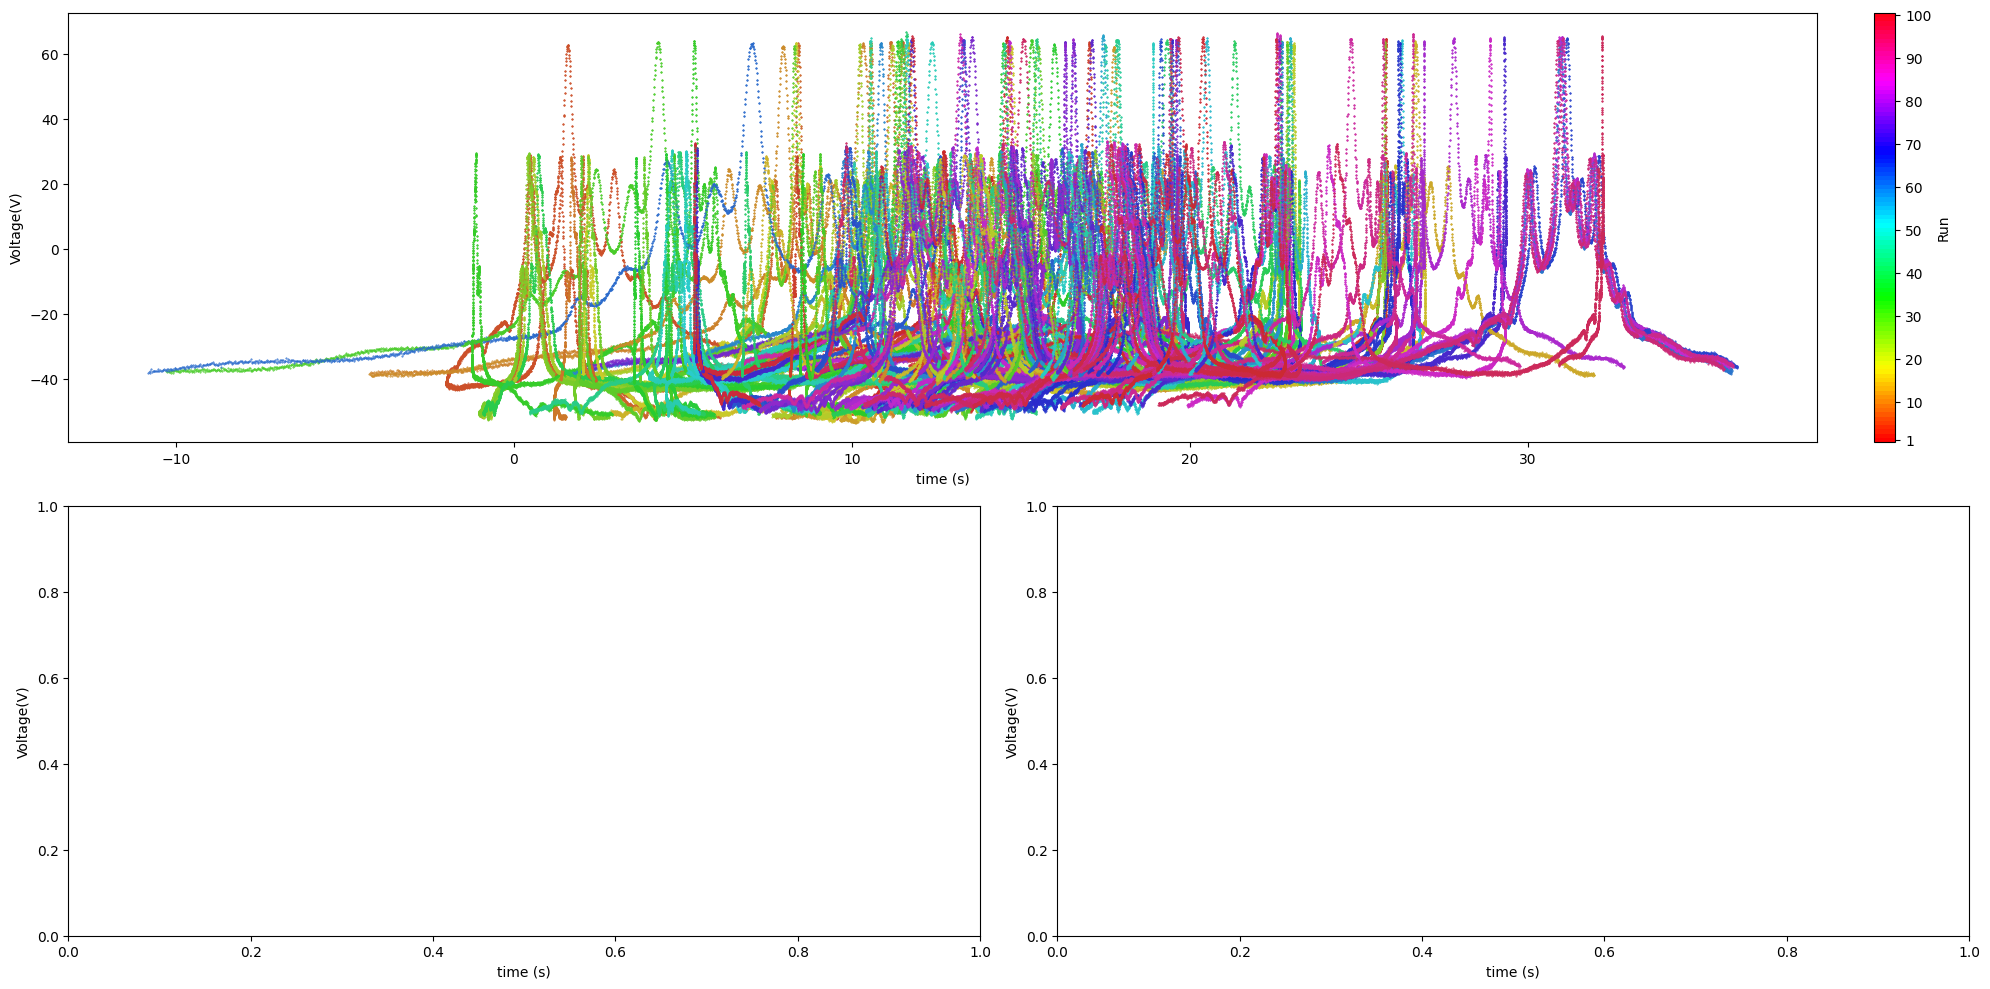

In [17]:


fig, axs = plt.subplots(2,2,figsize=(20,10))
gs = axs[1, 1].get_gridspec()
for ax in axs[0, :]:
    ax.remove()
axbig = fig.add_subplot(gs[0, :])

#add the colour bar
fig.colorbar(cm.ScalarMappable(cmap='hsv'),ax=axbig,label="Run",ticks=[1,10,20,30,40,50,60,70,80,90,100],boundaries=np.linspace(0.5,100.5,101),values=np.linspace(0,0.99,100),fraction=0.05,pad=0.03)

#the full spectrum
for i in range(100):
    spec=v[i,3000:7500]
    x=ts[i,3000:7500]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(x,spec,s=0.2,color=col)

for i in range(100):
    spec=v[i,6100:7000]
    x=ts[i,6100:7000]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(x,spec,s=0.2,color=col)

for i in range(100):
    spec=v[i,3800:4300]
    x=ts[i,3800:4300]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(x,spec,s=0.2,color=col)

axbig.set_xlabel("time (s)")
axs[1,0].set_xlabel("time (s)")
axs[1,1].set_xlabel("time (s)")
axbig.set_ylabel("Voltage(V)")
axs[1,0].set_ylabel("Voltage(V)")
axs[1,1].set_ylabel("Voltage(V)")

fig.tight_layout()

In [13]:
import winsound
frequency = 2300  # Set Frequency To 2500 Hertz
duration = 2000  # Set Duration To 1000 ms == 1 second
winsound.Beep(frequency, duration)